In [1]:
# Import libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# import the metrics class
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import std
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("College.csv")
X = df.iloc[:,1:]    
y = df["Private"]

In [3]:
label_encoder = LabelEncoder()
encoded_data = label_encoder.fit_transform(y)
y = encoded_data

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#Create a svm Classifier
clf = svm.SVC(kernel='linear') # Linear Kernel

#Train the model using the training sets
clf.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

print("Accuracy :")
acc = accuracy_score(y_test,y_pred)
print(acc)

Accuracy :
0.9203084832904884


In [7]:
# Reload the data
df = pd.read_csv("College.csv")
X = df.iloc[:,1:]    
y = df["Private"]

label_encoder = LabelEncoder()  # LabelEncoder is used for the labels, in order to have labels for d categories replaced with integers from 1 to d.
encoded_data = label_encoder.fit_transform(y)
y = encoded_data

ss = StandardScaler() # StandardScaler must be used for the training and test data, not for the labels. 
# It outputs positive or negative float. 
# That is why we should certainly not apply StandardScaler to the label variable. 
# Because the label column must be a positive integer. It can not be negative integer.
encoded_data = ss.fit_transform(X)
X = encoded_data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

#Create a svm Classifier
clf = svm.SVC(kernel='linear') # Linear Kernel

#Train the model using the training sets
clf.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

print("Accuracy :")
acc = accuracy_score(y_test,y_pred)
print(acc)

Accuracy :
0.9280205655526992


In [8]:
# Use scikit learns grid search to select the best hyperparameter for a non-linear SVM, and identify the model with the best score and its parameters. 
# [Hint: Refer to model_selection module of Scikit learn] 

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Reload the data
df = pd.read_csv("College.csv")
X = df.iloc[:,1:]    
y = df["Private"]

label_encoder = LabelEncoder()  # LabelEncoder is used for the labels, in order to have labels for d categories replaced with integers from 1 to d.
encoded_data = label_encoder.fit_transform(y)
y = encoded_data

ss = StandardScaler() # StandardScaler must be used for the training and test data, not for the labels. 
# It outputs positive or negative float. 
# That is why we should certainly not apply StandardScaler to the label variable. 
# Because the label column must be a positive integer. It can not be negative integer.
encoded_data = ss.fit_transform(X)
X = encoded_data

# Splitting the dataset into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fitting the Non-linear SVM classifier to the training set with RBF kernel
non_linear_svm = SVC(kernel='rbf')
non_linear_svm.fit(X_train, y_train)
# Predicting the test set results for Non-linear SVM
non_linear_predictions = non_linear_svm.predict(X_test)
# Calculate accuracy for Non-linear SVM
non_linear_accuracy = accuracy_score(y_test, non_linear_predictions)
# Creating the confusion matrix for Non-linear SVM
cm_non_linear = confusion_matrix(y_test, non_linear_predictions)

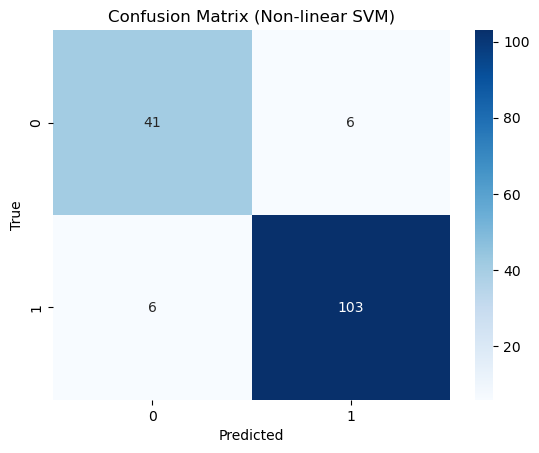

In [10]:
# Data Visualization for Non-linear SVM
sns.heatmap(cm_non_linear, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Non-linear SVM)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [11]:
# Display results for Non-linear SVM
print("Non-linear SVM (RBF kernel) Accuracy:", non_linear_accuracy)

Non-linear SVM (RBF kernel) Accuracy: 0.9230769230769231
